In [60]:
import env
import agent
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import time

In [63]:

def check(state_Q_key):

    return jnp.logical_not(jnp.logical_or(state_Q_key[0] == 224,jnp.isin(state_Q_key[0],jnp.array([31,107,63, 154, 20, 186, 112, 32, 144, 55, 176, 87,208]))))






master_key = jax.random.key(0)
keys = jax.random.split(master_key, 100000)

#metric counters
total_step_counts = 0

#tabQ must remain between runs
tabQ = jnp.zeros((225,4))


#needed for functions
epsilon = 0.1
gamma = 0.9
alpha = 0.5


def single_episode_gridworld(tabQ,key):

    steps = 0
    state = 0
    state_Q = (state, tabQ, key, steps)

    def b_func(state_Q_key):
        k1,k2 = jax.random.split(state_Q_key[2])
        policy = agent.epsilon_greedy(state_Q_key[0], state_Q_key[1], epsilon,k1)
        nstate,reward = env.gridworld(state_Q_key[0], policy)
        tabQ = agent.agent_updater(state_Q_key[0], policy, reward, nstate, state_Q_key[1], gamma, alpha)
        return (nstate, tabQ, k2, state_Q_key[3]+1)
    
    #runs a single episode. nstate = current state, tabQ is, Q estimates, k2 is split key
    state_Q  = jax.lax.while_loop(check, b_func, state_Q)
    win_loss = state_Q[0] == 224
    fsteps = state_Q[3]

    #returns (nstate, tab)
    return (state_Q[1],(win_loss, fsteps))



In [64]:
def multi_episode(tabQ, key):
    tab, (win_loss, fsteps) = jax.lax.scan(single_episode_gridworld, tabQ, key)
    return  tab, win_loss, fsteps

start = time.time()
final_tab, win_loss, episode_steps = multi_episode(tabQ, keys)

# Force JAX to finish computing before stopping the clock
episode_steps.block_until_ready() 

print(f"True execution time: {time.time() - start} seconds")

win_ints = win_loss.astype(jnp.int32)
cumalitive_wins = jnp.cumsum(win_ints)
window_size = 100
rolling_win_rate = np.convolve(win_ints, np.ones(window_size)/window_size, mode='valid')
rolling_steps = np.convolve(episode_steps, np.ones(window_size)/window_size, mode='valid')


True execution time: 7.580146789550781 seconds


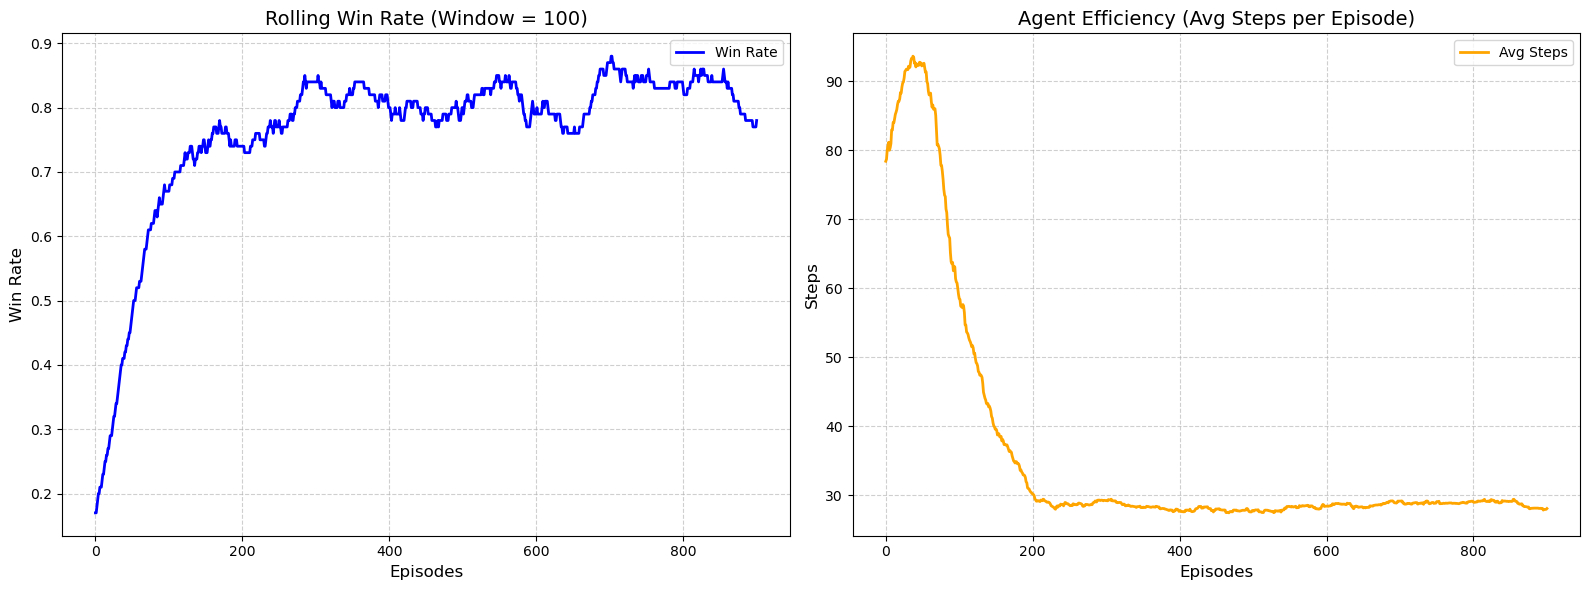

In [59]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left Plot: Win Rate
ax1.plot(rolling_win_rate, color='b', linewidth=2, label='Win Rate')
ax1.set_title('Rolling Win Rate (Window = 100)', fontsize=14)
ax1.set_xlabel('Episodes', fontsize=12)
ax1.set_ylabel('Win Rate', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Right Plot: Steps per Episode
ax2.plot(rolling_steps, color='orange', linewidth=2, label='Avg Steps')
ax2.set_title('Agent Efficiency (Avg Steps per Episode)', fontsize=14)
ax2.set_xlabel('Episodes', fontsize=12)
ax2.set_ylabel('Steps', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

# Clean up spacing and display
plt.tight_layout()
plt.show()